(sec:deep-learning)=
# 深層学習による画像識別

前章の[PyTorchと自動微分](#sec:pytorch)では、PyTorchにおけるテンソルの扱い方と自動微分の仕組み、そして自動微分を利用した最適化の方法について学んだ。

本章では、それらを土台として、実際にニューラルネットワークを構築し、画像を識別するモデルを学習させる手順を見ていく。題材には、国立国会図書館が公開している平仮名の文字画像データセットを用いる。

**Google Colab用の準備**

In [ ]:
IN_COLAB = True
try:
    import google.colab

    print('You are running the code in Google Colab.')
except ImportError:
    IN_COLAB = False
    print('You are running the code in the local computer.')

if IN_COLAB:
    # PyTorchのインストール
    !pip install torch torchvision
    pass

You are running the code in the local computer.


In [ ]:
import os

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from matplotlib.gridspec import GridSpec

# 実験に使うサンプル数
epochs = 5
batch_size = 32

# グラフの設定
rc = {'figure.dpi': 150}
sns.set_theme(style='white', palette='colorblind', rc=rc)
color_palette = sns.color_palette('colorblind')

In [ ]:
# | label: deep-learning-epochs
print(f'{epochs}')

**平仮名データセットの準備**

In [ ]:
import zipfile

import requests

url = 'http://lab.ndl.go.jp/dataset/hiragana73.zip'
filename = os.path.basename(url)

# HTTPリクエストを送ってデータサイズを取得
r = requests.get(url, stream=True)
total_size = int(r.headers.get('content-length', 0))
chunk_size = 65535

# "hiragana73"フォルダが存在し、その中身が空でないことを確認
if not os.path.exists('./hiragana73') or len(os.listdir('./hiragana73')) == 0:
    # 実際のファイルのダウンロード
    pbar = tqdm(total=total_size, unit='B', unit_scale=True)
    with open(filename, 'wb') as f:
        for data in r.iter_content(chunk_size):
            f.write(data)
            pbar.update(chunk_size)

    # ダウンロードが完了したらZIPを展開する
    with zipfile.ZipFile(filename, 'r') as f:
        f.extractall()

## 多層パーセプトロンによる学習

PyTorchを使った深層学習をするために準備すべきことはいくつかある。以下では、

- [データローダの準備](#ssec:dataloader-preparation)
- [ネットワークの構築](#ssec:network-architecture)
- [オプティマイザの準備](#ssec:optimizer-preparation)
- [損失関数の設定](#ssec:loss-function)
- [学習ループの実装](#ssec:training-loop)

のそれぞれについて順に説明する。

(ssec:dataloader-preparation)=
### データローダの作成

データローダとは、PyTorchを用いたニューラルネットワークの学習において、ミニバッチ学習を簡単にするための仕組みである。通常、深層学習には大量の訓練データが必要であり、それら全てを考慮したパラメータの更新方向(=勾配)を求めることは現実的ではない。

そこで、大量の訓練データから少数のデータ、すなわちミニバッチをサンプルし、そのミニバッチ内のデータによって与えられる勾配が、データ全体から求まる勾配の近似として十分に正しく動作することを仮定する。データから収集してくるミニバッチの数は`torch.utils.data.Dataset`型のサブクラスとして用意されたデータセット・クラスを引数にとる`torch.utils.data.DataLoader`によって制御できる。

では、上記のひらがなデータセットについて、まずはデータの読み出しを行う役割を持つデータセット・クラスを作成してみよう。なお、このデータセットには濁音・半濁音を含む73種類の文字が収録されているが、[特徴量抽出](#sec:feature-extraction)のときと同様に、ここでも濁音・半濁音・小文字を含まないひらがな46文字だけを扱うことにする。データセット・クラスは`torch.utils.data.Dataset`型のサブクラスとして実装する。この際、コンストラクタと合わせて、データの総数を返す`__len__`関数と、データ1つをサンプルする`__getitem__`関数の二つを実装する。

In [ ]:
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader


class HiraganaDataset(Dataset):
    """
    ひらがな46文字データセット
    """

    CHARS = 'あいうえおかきくけこさしすせそたちつてとなにぬねのはひふへほまみむめもやゆよらりるれろわをん'
    N_IMAGES_PER_CHAR = 200

    def __init__(self, dataroot, transform=None):
        super().__init__()

        self.dataroot = dataroot
        self.transform = transform
        self.n_classes = len(self.CHARS)

        # 各ひらがなの画像が入っているフォルダを列挙
        char2num = {c: i for i, c in enumerate(self.CHARS)}
        folders = [f'U{ord(c):04X}' for c in self.CHARS]
        folders = [os.path.join(self.dataroot, d) for d in folders]

        # 各フォルダに含まれる画像ファイルを列挙、配列に格納
        self.data = []
        for d in folders:
            char = os.path.basename(d).replace('U', '0x')
            char = chr(int(char, 16))
            num = char2num[char]

            image_files = [os.path.join(d, f) for f in os.listdir(d)]
            image_files = [f for f in image_files if f.endswith('.png')]
            if len(image_files) > self.N_IMAGES_PER_CHAR:
                image_files = np.random.choice(image_files, self.N_IMAGES_PER_CHAR, replace=False)

            image_files = sorted(image_files)
            self.data.extend([(f, num) for f in image_files])

    def __len__(self):
        """ファイルの総数を返す"""
        return len(self.data)

    def __getitem__(self, idx):
        """データ1つをサンプルする"""
        image_file, num = self.data[idx]
        try:
            image = Image.open(image_file)
        except OSError as e:
            raise OSError(f'Failed to load image: {image_file:s}') from e

        if self.transform is not None:
            image = self.transform(image)

        return image, num

さて、上記のデータセット・クラスにはコンストラクタの引数に`transform`という変数が渡されている。PyTorchではTorchVisionの`transforms`モジュールに用意されたデータ操作のためのクラスを用いることで、簡単にデータの前処理を行うことができる。

なお、PyTorch 2.0以降は`transforms.v2`という新しいモジュールが導入されており、従来の`transforms`よりも幅広いタスクを前処理に追加することができる ([参考](https://pytorch.org/vision/main/auto_examples/transforms/plot_transforms_getting_started.html))。本項でも`v2`を使用して前処理を行なっていく。

`transforms`を用いると、例えば、[特徴量の抽出](#sec:feature-extraction)で行っていたような

- 画像をグレースケールに変更
- 画像をランダムに回転、拡大・縮小

といった操作は `v2.GrayScale`や`v2.RandomAffine`によって実現することができる。複数の前処理操作を組み合わせる場合には、`v2.Compose`に前処理を行うクラス・インスタンスの配列を渡せば良い。

PyTorchの学習には、`torch.Tensor`型かつ`float32`型の変数を用いるので、上記の二つの前処理と合わせて、型の変換を行う`v2.ToImage` (`torch.Tensor`型への変更)と`v2.ToDtype` (データ内部の数値型を指定された型に変更する)を`v2.Compose`に与えている。

In [ ]:
# TorchVision
from torchvision.transforms import v2

transform = v2.Compose(
    [
        v2.Grayscale(),  # 画像のグレースケール化
        v2.RandomAffine(degrees=[-60, 60], scale=[0.8, 1.1]),  # ランダム回転、拡大・縮小
        v2.ToImage(),  # torch.Tensorに型変換
        v2.ToDtype(torch.float32, scale=True),  # データ型を32bit浮動小数に変換
    ]
)

`transform`の準備ができたら、これを前処理計算として、データセット・クラスをインスタンス化する。

In [ ]:
dataset = HiraganaDataset(dataroot='hiragana73', transform=transform)
n_classes = dataset.n_classes
print(f'{len(dataset):d} images from {n_classes:d} classes')

9200 images from 46 classes


このようにして作られたデータセットクラスはscikit-learnの時と同様に `torch.utils.data.random_split`関数を使うことで、訓練用とテスト用にデータを分割することができる。

In [ ]:
train_data, test_data = torch.utils.data.random_split(dataset, lengths=[0.8, 0.2])
print(f'#train: {len(train_data):d}, #test: {len(test_data):d}')

#train: 7360, #test: 1840


データセットの分割が完了したら、最後に`torch.utils.data.DataLoader`のインスタンス化を行う。このクラスはデータに対するイテレータとして用いることができ、予め`batch_size=...`で指定した数のデータを含むミニバッチを順に取り出してくれる。この際、データの順序をランダムにシャッフルするかどうかは`shuffle=...`で制御できる。訓練データはシャッフルを行い、テストデータはシャッフルを行わないで用いることが多い。

In [ ]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

:::{admonition} 練習問題
:class: question

`train_loader`から1つ目のミニバッチを取り出し、そこに含まれる画像のテンソルとラベルのテンソルの`shape`と`dtype`を確かめよ。

また、画像のテンソルの各次元が何を表わしているのかを説明せよ。
:::

:::{admonition} 練習問題
:class: question

`DataLoader`の引数`shuffle`について、訓練データではシャッフルを行い、テストデータでは行わないのが一般的である。

訓練データをシャッフルしないで学習を行うと、何が問題になるだろうか。データセット・クラスが画像を文字の順に並べていることを踏まえて考えよ。
:::

(ssec:network-architecture)=
### ネットワークの構築

学習可能なニューラルネットワークは`nn.Module`クラスを継承することで作成できる。まずは、単純な実装として、ひらがなの画像 (48×48画素)を2304次元ベクトルとして扱う場合について見てみる。

今回は、扱うひらがなの種類が46種類であるので、ネットワークが出力するべきものは46次元のベクトルで、それぞれの要素が、画像がどのひらがならしいかを表わす確率であるようなものである。

このようなベクトルからベクトルへの変換をいわゆる全結合層の連結によって表わすようなネットワークを特に**マルチレイヤ・パーセプトロン**(multilayer perceptron)やMLPと呼ぶ。

#### 全結合層

**全結合層** (fully-connected layer)は、入力のベクトル$\mathbf{x} \in \mathbb{R}^n$に対して、**重み行列** $\mathbf{W} \in \mathbb{R}^{m \times n}$と**バイアスベクトル** $\mathbf{b} \in \mathbb{R}^m$を使って

$$
\mathbf{y} = \mathbf{W} \mathbf{x} + \mathbf{b}
$$ (eq:fully-connected)

のように$\mathbf{y} \in \mathbb{R}^m$に変換する操作を表わす。従って、全結合層における学習可能なパラメータは$\mathbf{W}$と$\mathbf{b}$ということになる。

この全結合層が行う操作は{eq}`eq:fully-connected`から分かるように**線形の演算**である。

現在の深層学習においては、以下に示す畳み込みニューラルネットで用いられる畳み込み層など、学習可能なパラメータを含む操作は多くの場合、線形の演算によって定義されることがほとんどである。

#### 活性化関数

しかし、線形の操作を入力のベクトルに対して何回繰り返したところで、それは所詮線形の操作に他ならない。通常の機械学習において扱う入出力の関係は線形なものばかりではないので、深層学習以前にはカーネル法などを用いて非線形な関係を学習するなどの工夫を取り入れていた。

深層学習においては、学習可能なパラメータを含む演算を線形演算で表わす代わりに非線形の**活性化関数**を用いて、ニューラルネットが表わす入出力データの関係に非線形性を持たせる。

現在の深層学習において、最も広く用いられている活性化関数は**ReLU** (rectified linear unit)と呼ばれるものである。この関数は入力の正の部分だけを残すような関数で、式としては

$$
f_\text{ReLU}(x) = \begin{cases}
    0 & (x < 0) \\
    x & (\text{otherwise})
\end{cases}
$$

のように書ける。

以前は、このような活性化関数として、ソフトな閾値関数であるシグモイド関数が使われていた。シグモイド関数$\sigma(x)$は

$$
\sigma(x) = \frac{1}{1 + \exp(-x)}
$$

のような関数であり、以下のようなグラフを取る。

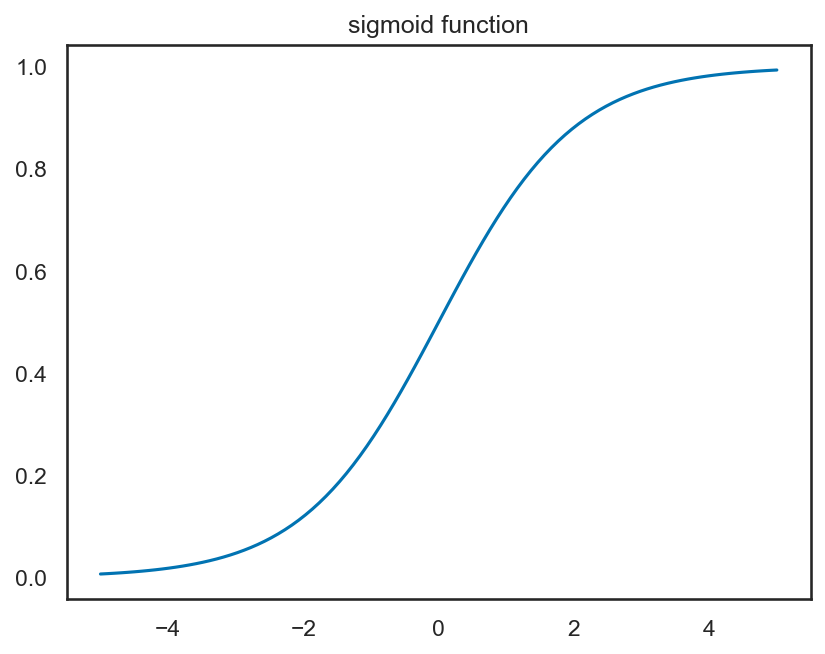

In [ ]:
x = np.linspace(-5.0, 5.0, 100)
y = 1.0 / (1.0 + np.exp(-x))
plt.plot(x, y)
plt.title('sigmoid function')
plt.show()

このように、シグモイド関数は入力が大きい時に1に近い値を、入力が小さい時に0に近い値を返すようなものであり、これが人間のニューロン同士の結びつきをうまく表わしていると考えられていた。

しかし、実際にニューラルネットの学習を数値計算によって実現しようとする場合、シグモイド関数による活性化は**勾配消失**の問題を引き起こすことが分かった。

勾配消失とは、連鎖律によって、入力の値に関する出力の勾配を求めていく過程で、小さな値が何度もかけ算され、数値誤差により勾配が0になってしまう現象である。シグモイド関数の微分は、

$$
\sigma'(x) = \frac{e^{-x}}{(1 + e^{-x})^2}
$$

なのだが、これは、元のシグモイド関数を用いて、

$$
\sigma'(x) = \sigma(x) (1 - \sigma(x))
$$

のように書き直せる。シグモイド関数の性質から$x$が正負どちらかの方向に大きな値をとれば、1あるいは0に近づいていくため、シグモイド関数の微分$\sigma'(x)$は、入力の$x$が0から外れた値を取ると、急激に小さくなることが分かる。

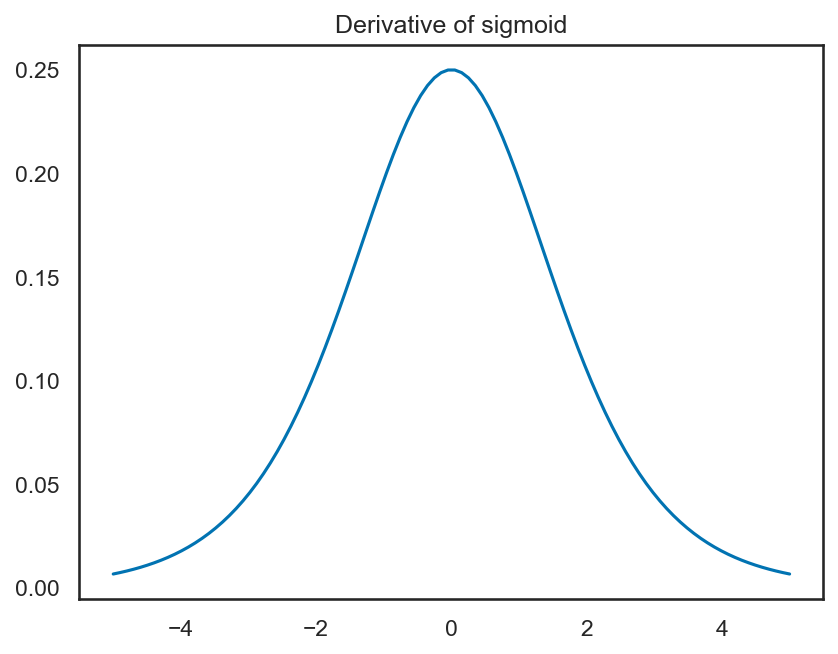

In [ ]:
x = np.linspace(-5.0, 5.0, 100)
sigmoid = lambda x: 1.0 / (1.0 + np.exp(-x))
y = sigmoid(x) * (1.0 - sigmoid(x))
plt.plot(x, y)
plt.title('Derivative of sigmoid')
plt.show()

この勾配消失により、ニューラルネットの入力に近い側の層において学習が上手く進まないことが長く問題とされてきたが、ReLUは、その導関数が0か1なので、シグモイド関数で問題となっていたような勾配消失の問題が起きづらくなっている。

このような理由から、現在の深層学習においてはReLUおよび、その変形を活性化関数として用いることが多いのである。

#### データ正規化

現在の深層学習においては、バッチ正規化 (batch normalization)を始めとしたデータ正規化をネットワーク上に配置することが多い。これは、スケールの異なるデータに対して、ニューラルネットがパラメータを統一的に学習するのに役立つ。

例えば、バッチ正規化の場合、ミニバッチに含まれるデータに対して計算されている特徴の平均と分散をミニバッチ内で計算し、データの平均が0、標準偏差が1となるように正規化を行う。

この効果はバイアスベクトルを例に取ると分かりやすい。もしデータ正規化を行わない場合、ニューラルネットは輝度がとある画像と輝度が一様に持ち上がった画像を区別するために、異なるバイアスベクトルを学習しなければならない。

しかし、データ正規化によってデータの平均値が0になるように正規化されていれば、一様に輝度が持ち上がるなどの変化を学習パラメータの違いによって判別する必要がなくなるため、よりニューラルネットの学習が効率的に進むようになる。

ただし、このようなデータ正規化は正規化を行うデータ群 (バッチ正規化であればミニバッチ)が、元のデータセットに含まれるデータの分布を上手く近似できていることを仮定しているので、ミニバッチのサイズが小さく、データ分布の近似的精度が悪い場合には、学習が逆に上手く進まないこともあるので注意すること。

なお、PyTorchを始めとする深層学習用のライブラリにおいて、データ正規化のモジュール(`nn.BatchNorm1d`や`nn.InstanceNorm1d`など)は単なるバッチ内でのデータの正規化に加えて、さらに平均と標準偏差を調整するようなパラメータを学習可能変数として持っている。

#### 単純なマルチレイヤ・パーセプトロン

では、ここまでの議論を踏まえて、単純なマルチレイヤ・パーセプトロンを実装してみる。PyTorchにおいては、**学習可能パラメータを含むモジュールはコンストラクタで定義しておく必要がある**ため、以下のコードでは、全結合層を表わす`nn.Linear`と、バッチ正規化を表わす`nn.BatchNorm1d`をコンストラクタの中でインスタンス化しておく。

今回、活性化関数として用いるReLUは学習可能パラメータを持たないので、こちらは、特にコンストラクタでは用意せずに、実際のネットワークが表わす関数の評価処理に対応する`forward`関数の中で`torch.relu`を呼び出す。

理由については後述するが、最終の全結合層に対する活性化関数には単なるソフトマックス関数ではなく、対数ソフトマックス関数を取る方が良い。

In [ ]:
class Network(nn.Module):
    """
    シンプルなマルチレイヤ・パーセプトロン
    """

    def __init__(self, in_features, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, out_features)

    def forward(self, x):
        x = self.bn1(self.fc1(x))
        x = torch.relu(x)
        x = self.bn2(self.fc2(x))
        x = torch.relu(x)
        x = self.fc3(x)
        y = F.log_softmax(x, dim=1)
        return y

また、PyTorchには`nn.Module`のサブクラスである`nn.Sequential`があり、ニューラルネットを構成するモジュールを引数として与えることで、それを順に実行させることもできる。すると、上記の実装はもう少しすっきりと以下のように書ける。

In [ ]:
class Network(nn.Sequential):
    """
    nn.Sequentialを継承した例
    """

    def __init__(self, in_features, out_features):
        super().__init__(
            nn.Linear(in_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Linear(32, out_features),
            nn.LogSoftmax(dim=1),
        )

このようにして実装したニューラルネットは入出力の次元数を与えて、以下のようにインスタンス化しておく。

In [ ]:
model = Network(48 * 48, n_classes)

このようにしてモデルを作成したら訓練時には`model.train()`を、評価時には`model.eval()`を予め呼び出しておく (後述のソースコードを参照)。

`train()`や`eval()`を呼び出すと、バッチ正規化や後述するドロップアウトの挙動が変化するため、必ずしも訓練時と同じデータでも同じ精度が出ない可能性があることに留意したい。

(ssec:optimizer-preparation)=

:::{admonition} 練習問題
:class: question

上記の`Network`について、`model.parameters()`から学習可能なパラメータの総数を求めよ。

また、その内訳を全結合層ごとに求め、どの層が最も多くのパラメータを持っているかを確かめよ ($n$ 次元から $m$ 次元への全結合層のパラメータ数が $mn + m$ であることを思い出すこと)。
:::

:::{admonition} 練習問題
:class: question

活性化関数のReLUを、シグモイド関数 (`torch.sigmoid`)に置き換えて学習を行い、損失関数の下がり方がどのように変わるかを比べよ。また、その違いを勾配消失の観点から説明せよ。
:::

### オプティマイザの準備

やや天下り式ではあるが、今回は、多くの問題に対して、それなりに良い性能を発揮するAdamをオプティマイザに用いる。ニューラルネットの学習可能パラメータは`parameters`関数で得られるので、これをオプティマイザの第一引数に指定する。

In [ ]:
optim = torch.optim.Adam(model.parameters(), lr=1.0e-3)

(ssec:loss-function)=
### 損失関数の設定

**損失関数** (loss function)は、ニューラルネットを訓練するための基準を決める関数であり、問題の種類ごとに、おおよそどのような関数を使えば良いかが決まっている。

識別問題の場合には、2クラス分類なら二値交差エントロピー (binary cross entropy)を、多クラス分類なら交差エントロピー(cross entropy)を用いるのが一般的である。これらを$\mathcal{L}_{\rm BCE}$, $\mathcal{L}_{\rm CE}$と書くことにすると、それぞれ以下の式で表わされる。

$$
\begin{align}
\mathcal{L}_{\rm BCE} &= - y \log x - (1 - y) \log (1- x) \\
\mathcal{L}_{\rm CE} &= - y \log x
\end{align}
$$

なお、$y \in \lbrace 0, 1\rbrace$, $x \in [0, 1]$はそれぞれ正解のラベルと、予測のラベルを表わす。

交差エントロピーには、回帰問題で一般的に用いられる最小二乗誤差などと比べて、ラベルが正解から外れている時に、大きなペナルティが与えられる、という特徴があるため、より分類問題に向いた誤差指標と言える。

多クラス分類では、ネットワークの出力を確率のように扱うために、最終層を**ソフトマックス関数**によって活性化するのが一般的である。活性化前の特徴ベクトルを$\mathbf{x}$とすると、活性化後のラベル$\mathbf{y}$の各次元$y_d$は、以下の式で与えられる。

$$
y_d = \frac{e^{x_d}}{\sum_{j} e^{x_j}}
$$

ただし、前述のネットワークでは、最終層の活性化関数にソフトマックス関数ではなく**対数ソフトマックス関数**を用いていた。これは、ソフトマックス関数をそのまま計算すると、指数関数によるオーバーフローやアンダーフローが起こり、その対数を取る交差エントロピーの計算にも影響が及ぶためである。この点の詳細については「[発展: ソフトマックス関数の数値計算](#ssec:softmax-numerics)」で扱う。

さて、対数ソフトマックス関数の出力を$z$とすれば、交差エントロピーは

$$
\mathcal{L}_{\rm CE} = -y z
$$

のように書き直せる。この関数こそが**負の対数尤度誤差** (negative log-likelihood)であり、PyTorchでは`nn.NLLLoss`として用意されている。

以上の議論から、より高精度な識別結果を得るためには、

- 最終層を対数ソフトマックス関数 (`nn.LogSoftmax` or `F.log_softmax`)で活性化する
- 損失関数に負の対数尤度誤差 (`nn.NLLLoss`)を用いる

という工夫を行なうのが良い。

PyTorchにおいては、慣習的に`criterion`という変数に損失関数を取ることが多く、それに倣って、以下のように`NNLLoss`クラスをインスタンス化しておく。

In [ ]:
# 損失関数の準備
criterion = nn.NLLLoss()

:::{admonition} NLLLossとCrossEntropyLoss
:class: note

前述の説明では、単純なソフトマックス関数を分類問題の活性化関数として利用することの危険性を示すために、あえて対数ソフトマックス関数を明示的に使用する方法について述べた。

ただし、PyTorchの多クラス分類用の損失関数クラスである`CrossEntropyLoss`は、活性化されていない最終出力と、クラスインデックスの集合を引数として与えると、内部で対数ソフトマックスの適用と`NLLLoss`同様の損失関数の計算を行なってくれる。

従って、ソフトマックス関数の問題と各損失関数の仕組みを正しく理解しているなら`CrossEntropyLoss`を使っても良い。

:::

:::{admonition} 練習問題
:class: question

`nn.NLLLoss`と`nn.CrossEntropyLoss`について、同じ入力に対して同じ損失の値が得られることを確かめよ。

ただし、`nn.NLLLoss`には対数ソフトマックス関数を適用した後の値を、`nn.CrossEntropyLoss`には活性化する前の値を与える必要があることに注意すること。
:::

(ssec:training-loop)=
### トレーニング・ループ

さて、ここまで準備ができたら、最後にニューラルネットワークを訓練するための繰り返し計算をforループによって実装しよう。

深層学習においては、トレーニングデータを何周分トレーニングするかを**エポック**という用語で表わす。以下の例では![](#deep-learning-epochs)周分、すなわち![](#deep-learning-epochs)エポックの学習を行なっている。

学習と同時に、進行状況が分かるようにしておくことはとても大事で、以下の例では`tqdm`モジュールを用いて、訓練の進み具合と、その時の損失関数の値、ならびに識別精度を表示するようにしている。

In [ ]:
# モデルの初期化
model = Network(48 * 48, n_classes)

# オプティマイザの初期化
optim = torch.optim.Adam(model.parameters(), lr=1.0e-3)

# トレーニング・ループ
losses = []
accuracies = []

model.train()
for epoch in range(epochs):
    # 進行状況の可視化
    pbar = tqdm(train_loader)
    for data in pbar:
        # 訓練データの取り出し
        X, y_true = data
        X = X.reshape((X.size(0), -1))

        # 推定と損失関数の評価
        y_pred = model(X)
        loss = criterion(y_pred, y_true)
        acc = (torch.argmax(y_pred, dim=1) == y_true).float().mean()

        losses.append(loss.item())
        accuracies.append(acc.item())

        pbar.set_description(f'[MLP] epoch={epoch + 1:d}, loss={loss.item():1.3f}, acc={acc.item():1.3f}')

        # 誤差逆伝搬によるパラメータの更新
        optim.zero_grad()
        loss.backward()
        optim.step()

  0%|          | 0/230 [00:00<?, ?it/s]

  0%|          | 0/230 [00:00<?, ?it/s]

  0%|          | 0/230 [00:00<?, ?it/s]

  0%|          | 0/230 [00:00<?, ?it/s]

  0%|          | 0/230 [00:00<?, ?it/s]

上記の学習について、誤差と精度の変化をプロットしてみる。そのままだと、上下の振動が大きく見づらいので、移動平均を取って曲線を滑らかにしておく。

In [ ]:
# 移動平均を取る (= ボックス・フィルタをかける)
box_size = 5
box = np.ones(box_size) / box_size

losses = np.convolve(losses, box, mode='valid')
accuracies = np.convolve(accuracies, box, mode='valid')

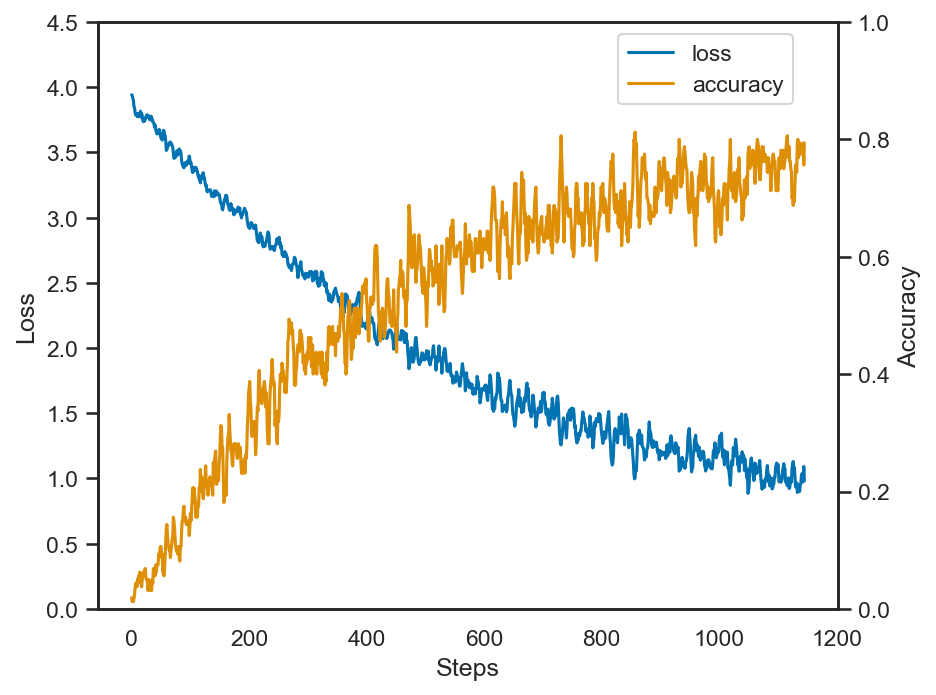

In [ ]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(np.arange(len(losses)), losses, label='loss', color=color_palette[0])
ax1.set_ylim(0.0, 4.5)
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss')
ax2.plot(np.arange(len(losses)), accuracies, label='accuracy', color=color_palette[1])
ax2.set_ylim(0.0, 1.0)
ax2.set_ylabel('Accuracy')
fig.legend(bbox_to_anchor=(0.85, 0.95))
plt.tight_layout()
plt.show()

In [ ]:
model.eval()
pbar = tqdm(test_loader)
n_succ = 0

for data in pbar:
    X, y_true = data
    X = X.reshape((X.size(0), -1))

    with torch.no_grad():
        y_pred = model(X)

    n_succ += (torch.argmax(y_pred, dim=1) == y_true).float().sum()

total_acc = n_succ / len(test_data)
print(f'Acc: {total_acc:.3f}')

  0%|          | 0/58 [00:00<?, ?it/s]

Acc: 0.707


このように、PyTorchを使ってニューラルネットワークを構築することで、一定の識別精度を得ることができた。

しかしながら、MLPにおいては画像を単純なベクトルとして扱うため、画像の空間的な情報を活かすことが出来ず、その結果はFisherベクトルを用いた場合の精度等には及ばない。

:::{admonition} 練習問題
:class: question

学習ループの中で`optim.zero_grad()`を呼び出さないとどうなるかを、実際に試して確かめよ。

また、そうなる理由を[PyTorchと自動微分](#sec:pytorch)の「勾配計算の制御」で述べた勾配の累積の観点から説明せよ。
:::

:::{admonition} 練習問題
:class: question

上記の学習ループでは、損失と精度をミニバッチごとに記録し、後から移動平均を取って滑らかにしている。

移動平均の窓幅`box_size`を変えたときに、グラフの見え方がどのように変わるかを確かめよ。また、窓幅を大きくしすぎると何が失われるかを考えよ。
:::

## 畳み込みニューラルネットによる学習

ここまでは、全結合層からなるマルチレイヤ・パーセプトロンによる学習を見てきたが、今回は取り扱う対象が画像であるため、**畳み込みニューラルネット**により、より効果的な学習が期待できる。

全結合層は、入力のベクトルに対して、行列を作用させて、さらにその結果にバイアスベクトルを加算する、というものであった。この操作は、畳み込みニューラルネットで用いられる**畳み込み層**においてもほとんど同じである。

今、入力が画像であり、それが画素ごとに特徴化されて$(H, W, D)$という大きさを持つデータであるとしよう。なお、$H$は画像 (特徴マップ)の高さ、$W$は幅、$D$は各画素が持つ特徴の次元である。

このデータを畳み込み層によって$(H', W', D')$に変換することを考える。畳み込み層が持つ学習可能な重みは、畳み込みカーネルを表わす二次元のマップであり、これが入力と出力のチャネルの組み合わせの数だけ、すなわち$D \times D'$個用意される。カーネルのサイズを$K\times K$とする場合、畳み込み前後の特徴マップのサイズには、

$$
\begin{align}
W' &= W - K + 1 \\
H' &= H - K + 1
\end{align}
$$

という関係がある。また、畳み込み層は、カーネルの大きさに加えて、何画素飛ばしでカーネルを適用するかを表わすストライド$S$と、画像の周りを何らかの値で埋めて、大きさを調整するパディング$P$をパラメータとして持つ。これらの値を加味すると、畳み込み前後の画像サイズの関係は、以下のように書き直せる。

$$
\begin{align}
W' &= \frac{W - K + 2P}{S} + 1 \\
H' &= \frac{H - K + 2P}{S} + 1
\end{align}
$$

現在は、ニューラルネットワークの畳み込み層で、画像や特徴マップのサイズを変更することは少なく、多くの場合、$P=(K-1)/2$, $S=1$とすることで、畳み込み前後のサイズが変わらないようにすることが多い。例えば、$3\times 3$の畳み込みを用いる場合、$P=1$, $S=1$と設定する。

その代わり、画像や特徴マップのサイズを変更する操作としてプーリングという操作を行なう。プーリングは、$2 \times 2$などの小さな画像領域において、その画素が持つ特徴の最大値や平均を取るような操作を指す。PyTorchにおいては、最大を取る操作が`nn.MaxPool2d`および`F.max_pool2d`に、平均を取る操作が`nn.AvgPool2d`および`F.avg_pool2d`に用意されている。

これらを用いて簡単な畳み込みニューラルネットを実装したものが以下である。

In [ ]:
class CNN(nn.Module):
    """
    畳み込みニューラルネット
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 32, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 16, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(16)
        self.fc3 = nn.Linear(6 * 6 * 16, out_channels)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))  # (B, 64, 48, 48)
        x = F.max_pool2d(x, 2)  # (B, 64, 24, 24)
        x = torch.relu(self.bn2(self.conv2(x)))  # (B, 32, 24, 24)
        x = F.max_pool2d(x, 2)  # (B, 32, 12, 12)
        x = torch.relu(self.bn3(self.conv3(x)))  # (B, 16, 12, 12)
        x = F.max_pool2d(x, 2)  # (B, 16, 6, 6)
        x = x.reshape((x.size(0), -1))  # (B, 16 * 6 * 6)
        x = self.fc3(x)  # (B, out_channels)
        y = F.log_softmax(x, dim=1)
        return y

ところで、これまで、学習はCPUを用いて計算してきたが、上記の畳み込みニューラルネットになってくると、CPUだけの計算では少々時間がかかるようになってくる。

そこで、GPUが使える環境ではGPUを使うようにデバイスの設定を行なう。GPU上ではNVIDIA社のCUDA (compute unified device architecture)を用いて計算が行なわれ、GPUの性能にもよるが、CPUより遙かに高速な学習が可能である。

CUDAが使えるかどうかの判定には`torch.cuda.is_available()`関数を用いる。

In [ ]:
# デバイスの判定
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Your device is', device)

Your device is cpu


デバイスが取得できたら、ネットワークならびに学習データを、デバイスに転送する操作が必要になる。具体的には、それぞれに用意された`to(...)`という関数に対して、上記の`device`インスタンスを指定する。

In [ ]:
# ネットワークおよびオプティマイザのインスタンス化
model = CNN(1, n_classes).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1.0e-3)

In [ ]:
losses = []
accuracies = []
model.train()
for epoch in range(epochs):
    pbar = tqdm(train_loader)
    for data in pbar:
        # データのデバイスへの転送
        X, y_true = data
        X = X.to(device)
        y_true = y_true.to(device)

        # 推論ならびに損失関数の評価
        y_pred = model(X)
        loss = criterion(y_pred, y_true)
        acc = (torch.argmax(y_pred, dim=1) == y_true).float().mean()

        losses.append(loss.item())
        accuracies.append(acc.item())

        pbar.set_description(f'[CNN] loss={loss.item():1.3f}, acc={acc.item():1.3f}')

        optim.zero_grad()
        loss.backward()
        optim.step()

  0%|          | 0/230 [00:00<?, ?it/s]

  0%|          | 0/230 [00:00<?, ?it/s]

  0%|          | 0/230 [00:00<?, ?it/s]

  0%|          | 0/230 [00:00<?, ?it/s]

  0%|          | 0/230 [00:00<?, ?it/s]

In [ ]:
# 移動平均を取る (= ボックス・フィルタをかける)
box_size = 5
box = np.ones(box_size) / box_size

losses = np.convolve(losses, box, mode='valid')
accuracies = np.convolve(accuracies, box, mode='valid')

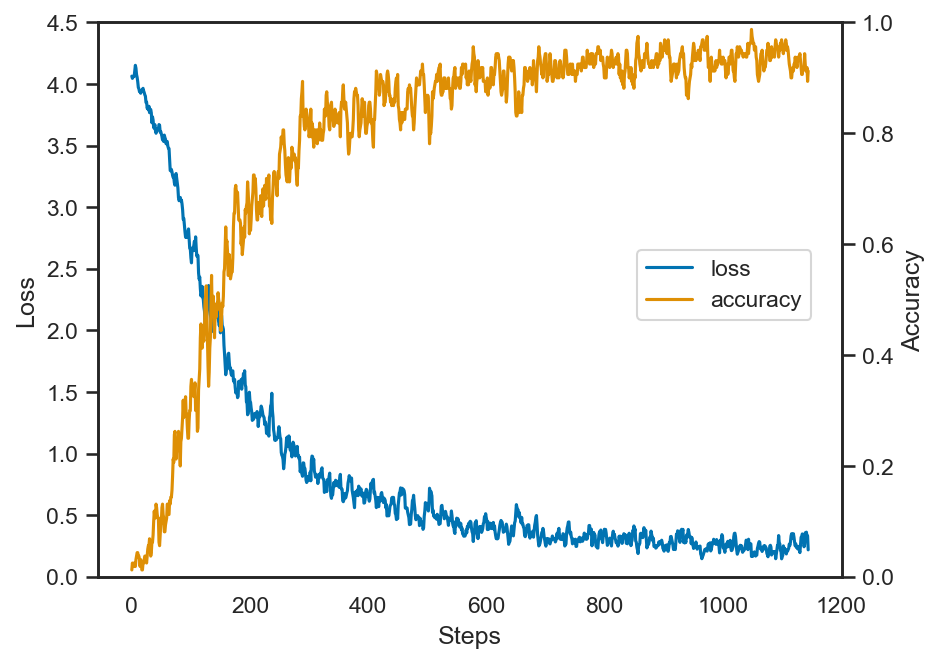

In [ ]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(np.arange(len(losses)), losses, label='loss', color=color_palette[0])
ax1.set_ylim(0.0, 4.5)
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss')
ax2.plot(np.arange(len(losses)), accuracies, label='accuracy', color=color_palette[1])
ax2.set_ylim(0.0, 1.0)
ax2.set_ylabel('Accuracy')
fig.legend(bbox_to_anchor=(0.88, 0.58))
plt.show()

In [ ]:
model.eval()
pbar = tqdm(test_loader)
n_succ = 0

for data in pbar:
    X, y_true = data
    X = X.to(device)
    y_true = y_true.to(device)

    with torch.no_grad():
        y_pred = model(X)

    n_succ += (torch.argmax(y_pred, dim=1) == y_true).float().sum()

total_acc = n_succ / len(test_data)
print(f'Acc: {total_acc:.3f}')

  0%|          | 0/58 [00:00<?, ?it/s]

Acc: 0.901


このようにCNNを用いて画像としての特徴をより意識するようなニューラルネットワークを用いたことで、識別の精度が大幅に向上したことが分かる。

:::{admonition} 練習問題
:class: question

MLPとCNNを用いた画像識別の各例について、オプティマイザの種類によって、誤差関数の収束と識別精度の上昇がどのように変化するかを調査せよ。
:::

:::{admonition} 練習問題
:class: question

上記の`CNN`と`Network` (MLP)について、それぞれの学習可能なパラメータの総数を比較せよ。

CNNの方が識別精度が高いにもかかわらず、パラメータ数はどうなっているだろうか。畳み込み層のパラメータが、入力の画像サイズによらずカーネルの大きさとチャネル数だけで決まることを踏まえて考察せよ。
:::

## 学習結果の保存

実際に深層学習をアプリケーションで使う際には、予め時間を掛けてニューラルネットワークを学習しておき、その学習結果だけを読み出して、応用に使用する場合がほとんどだろう。また、途中まで学習がされているネットワークを読み出して、そこから別のデータで**ファイン・チューニング**を行なう場合もあるだろう。

そのような時には、ネットワークのパラメータを`*.pth`ファイルに保存しておくことが一般的である。ネットワークやオプティマイザには、`state_dict()`関数が用意されていて、パラメータとその名前を格納した辞書を取得することができる。このような辞書がネストしたものを`torch.save`関数に渡すことで重みを保存することができる。

In [ ]:
ckpt = {
    'model': model.state_dict(),
    'optim': optim.state_dict(),
}
torch.save(ckpt, 'ckpt.pth')

このようにして、保存したパラメータは`torch.load`関数で辞書型として読み出すことができ、対応する辞書を`load_state_dict`関数に指定することでパラメータを上書きすることができる。

In [ ]:
# ネットワークとオプティマイザの別インスタンスを作成
model2 = CNN(1, n_classes)
model2.to(device)
optim2 = torch.optim.Adam(model2.parameters(), lr=1.0e-3)

# 学習済みパラメータの読み込み
ckpt2 = torch.load('ckpt.pth')
model2.load_state_dict(ckpt2['model'])
optim2.load_state_dict(ckpt2['optim'])

再度、読み込んだパラメータを用いて性能を確認してみる。

In [ ]:
model2.eval()
pbar = tqdm(test_loader)
n_succ = 0

for data in pbar:
    X, y_true = data
    X = X.to(device)
    y_true = y_true.to(device)

    with torch.no_grad():
        y_pred = model2(X)
    n_succ += (torch.argmax(y_pred, dim=1) == y_true).float().sum()

total_acc = n_succ / len(test_data)
print(f'Acc: {total_acc:.3f}')

  0%|          | 0/58 [00:00<?, ?it/s]

Acc: 0.897


このように、パラメータの読み込みにより、以前の結果を再現できていることが分かる。

なお、本項の例は`HiraganaDataset`の内部で画像を読み込むときに**評価時もランダム回転等を適用しているため、実行する度に多少精度が変化する**。

:::{admonition} 異なるデバイスでのパラメータの読み込み
:class: warning

学習を行ったデバイスと異なるデバイスで`.pth`ファイルを読み込む場合、単に `torch.load`を呼び出すだけでは`RuntimeError`になってしまう。

これを防ぐには`torch.load`の引数に`map_location=...`を指定して、どの種類のデバイスに読み込むのかを指定する。例えばCUDA上で学習を行って得たパラメータをCPU上で読み込む場合には、以下のようにすれば良い。

```python
ckpt = torch.load('ckpt.pth', map_location=torch.device('cpu'))
```

:::

(ssec:avoid-overfit)=
## 過学習を防ぐための工夫

上記のCNNによる文字分類の結果を見てみると、訓練時の精度と比較して、テスト時の精度がやや劣っていることが分かる。このような訓練データに対して、過度に高い精度が出てしまう現象を**過学習**と呼ぶ。

過学習を防ぐための方法にはいくつかあるが、主なものとして以下の4つが挙げられる。

- 学習可能なパラメータの数を減らす
- 訓練データ数を増やす
- 正則化項の追加
- ドロップアウトの導入

学習パラメータの数は、過学習の主要な原因の一つで、これはニューラルネットに限らず、モデルが複雑になればなるほど、必要な学習データの数が増す。これは、単純には、連立方程式における制約式の数と未知数の数の関係と同じであり、パラメータ数が多ければ制約を増やす意味で多くの訓練データが必要であり、訓練データの量が十分でないときには、より簡素な機械学習モデルを使う方が過学習の影響を抑えられる。

故に、どのような問題に対しても、**無差別に深層学習を適用すれば良い結果が得られるわけではない**、という点には最大の注意を払ってほしい。やはり、深層学習が発展した今でも、問題に応じて適切な手法を選ばなければならないことに変わりはない。

次に、訓練データ数を増やすことも、過学習を抑えるための直接的な方法である。とはいえ、実際の問題では、データを新たに集めること自体に費用や時間がかかることが多い。

そこで、手元にあるデータに対して、ラベルが変わらないような変換を加えることで、見かけ上のデータ数を増やす**データ拡張** (data augmentation)がよく用いられる。画像の場合であれば、平行移動、回転、拡大・縮小、左右反転、明るさの変更などが典型的な変換である。

実は、本章のデータセット・クラスに与えている`transform`は、既にこのデータ拡張を行なっている。

```python
v2.RandomAffine(degrees=[-60, 60], scale=[0.8, 1.1])
```

という前処理は、画像を読み出すたびにランダムな回転と拡大・縮小を加えるので、同じ画像ファイルからでも、毎回わずかに異なる画像が得られることになる。これにより、ネットワークは「少し回転していても同じ文字である」ことを学習でき、特定の見え方に過度に適合しにくくなる。

ただし、どのような変換を加えて良いかは問題によって決まる点に注意してほしい。例えば、数字の「6」と「9」を識別する問題で 180° の回転を加えてしまうと、ラベルが変わってしまい、学習が成立しなくなる。

なお、データ拡張は本来、訓練時にのみ適用し、評価時には適用しないのが一般的である。本章の実装は、データセット・クラスの内部で`transform`を適用しているため、評価時にもランダムな回転等がかかっており、テスト時の精度が実行のたびに多少変動する原因になっている。

また、正則化項の導入により過学習を防ぐことも可能である。正則化項とは、非常に大雑把な議論では、各パラメータの絶対値が大きくなりすぎないようにペナルティ項を追加することに対応する。このようなペナルティ項には様々な種類があるが、よく用いられるのはL1正則化、ならびにL2正則化である。L1正則化は学習可能パラメータの絶対値の和を使い、L2正則化は学習可能パラメータの二乗の和を用いる。

PyTorchを用いる場合、L2正則化であれば、オプティマイザをインスタンス化する際に引数として`weight_decay=...`というパラメータを指定することで、正則化がかかる。例えば、

```python
optim = torch.optim.Adam(model.parameters(), lr=1.0e-3, weight_decay=1.0e-6)
```

といった感じで、この場合には、パラメータの二乗和に対して`weight_decay=...`で指定した値が乗算されたものが損失関数に追加される。

一方、L1正則化を行ないたい場合には、陽にパラメータの大きさの絶対値の和を足し上げていく必要がある。

In [ ]:
# L1正則化の実装例
l1_reg = 0.0
for p in model.parameters():
    l1_reg += p.abs().sum()

最後に紹介するDropoutは、層の出力の一部をランダムに無効化しながら学習するという仕組みである。例えば、全結合層により、ベクトルの次元数を$D_1$から$D_2$に変える場合、Dropoutされる確率を$p \in (0, 1)$として、出力の$D_2$次元のうち、およそ$p D_2$個の要素を**訓練時のみ**ランダムに0で埋めてしまう (無効化されるのは重み行列の要素ではなく、層の出力である点に注意してほしい。重みの側を無効化するDropConnectという別の手法もある)。

こうすることにより、機械学習モデルは、どのパラメータを使った場合にも、まんべんなく訓練データに対する予測ができるように学習が進み、結果として過学習を防ぐことができる。

PyTorchで実装する場合には、活性化関数の後に`nn.Dropout`あるいは`F.dropout`を追加すれば良い。なお、PyTorchの`Dropout`に指定する確率は**パラメータを0で埋める割合**である (つまり`Dropout(p=0.0)`とすると、何もしないことと同義になる)。

:::{admonition} 練習問題
:class: question

[過学習を防ぐための工夫](#ssec:avoid-overfit)に示した方法によって、どの程度、過学習が抑制できるかを実際に試してみよ。

:::

:::{admonition} レイヤーの順序
:class: note

現在のニューラルネットワークにおいては、

- 全結合層、畳み込み層などの学習可能な線形操作
- バッチ正規化などのデータ正規化
- 活性化関数
- ドロップアウト

のような順序で演算を行なうことが多いが、この善し悪しについてはあまりはっきりとしないところがある。特に、データ正規化と活性化関数の順序については、その演算の意味を考えると、順序が逆の方が良いと思える部分も多い。

データ正規化の後に活性化関数をもってくる、という順序はバッチ正規化の原論文である{cite}`ioffe2015batch`で提唱された順序であり、多くの手法がこの順序を採用している。しかし、データ正規化がデータの平均を0に合わせることを考えると、その後に、負の値を0で埋めてしまうReLUを適用するのは、やや不適切に思えなくもない。

さらに言えば、データ正規化の効果は全結合層などの線形操作においてバイアスベクトルの学習を促進する効果にあるわけだから、線形操作の直前にデータ正規化が行なわれる方が自然である。

実際、「線形操作」→「活性化関数」→「ドロップアウト」→「データ正規化」の順序の方が性能が向上するという見方もある。このように、論文に書かれていることが常に正しいとは限らないので、論文を読むときには、多少は疑いの目をもって読むことが大事である。
:::

## 発展的な内容

ここから先の節は、講義の中では扱わない発展的な内容である。ソフトマックス関数を自分で実装する場合や、学習が数値的に不安定になる原因を調べたい場合に読んでほしい。

(ssec:softmax-numerics)=
### 発展: ソフトマックス関数の数値計算

#### Softmax関数の計算

さて、ここで一つ重要な問題がある。多クラス分類の場合、予測ラベルは、その値が0から1の範囲に収まるようにソフトマックス関数によって活性化されることが一般的である。活性化前の特徴ベクトルを$\mathbf{x}$とすると、活性化後のラベル$\mathbf{y}$の各次元$y_d$は、以下の式で与えられる。

$$
y_d = \frac{e^{x_d}}{\sum_{d} e^{x_d}}
$$

この式を見て分かる通り、ソフトマックス関数は分母と分子に指数関数を含むため、$\mathbf{x}$の要素が少し大きな値を取るだけで、ニューラルネットワークの学習に一般的に用いられる単精度浮動小数で表せる範囲を超えてしまう。

そのため、実際のソフトマックス関数の計算においては、予め分母と分子を$\mathbf{x}$のうち最大の要素を$\max_j x_j$として、$e^{\max_j x_j}$で割り算をしておく、ということをする。

より具体的には、以下の式によりソフトマックス関数を計算する。

$$
y_d = \frac{e^{x_d - \max_j x_j}}{\sum_{d} e^{x_d - \max_j x_j}}
$$

この違いを実際に計算して確かめてみよう。

In [ ]:
# 0-100の間の乱数
np.random.seed(3)
x = torch.tensor(np.random.uniform(0, 100, size=(10)), dtype=torch.float32)

# 単純な計算
softmax0 = torch.exp(x) / torch.exp(x).sum()

# 工夫した計算
max_x = torch.max(x)
softmax1 = torch.exp(x - max_x) / torch.exp(x - max_x).sum()

# 結果の表示
print(' Input:', x)
print('Simple:', softmax0)
print('Better:', softmax1)

 Input: tensor([55.0798, 70.8148, 29.0905, 51.0828, 89.2947, 89.6293, 12.5585, 20.7243,
         5.1467, 44.0810])
Simple: tensor([0., 0., 0., 0., nan, nan, 0., 0., 0., 0.])
Better: tensor([5.7665e-16, 3.9313e-09, 2.9778e-27, 1.0593e-17, 4.1712e-01, 5.8288e-01,
        1.9686e-34, 6.9264e-31, 1.1892e-37, 9.6426e-21])


いかがだろうか。このように、単純にソフトマックス関数を計算してしまうと、入力の$\mathbf{x}$に一つ、大きな値が含まれるだけで、計算に失敗してしまうことが分かる。自分でソフトマックス関数を書く場合には注意されたい (特にNumPyには標準のソフトマックス関数が実装されていない)。

#### SoftmaxとLogSoftmax

さて、続いてはソフトマックス関数(softmax)と、対数ソフトマックス関数(log-softmax)の違いについて見ていきたい。前述のニューラルネットワークでは、最終層の活性化関数に対してソフトマックス関数ではなく対数ソフトマックス関数を用いていたが、もちろんこれにも意味がある。

例えば、次の例を見てみてほしい。

In [ ]:
np.random.seed(3)
x = torch.tensor(np.random.uniform(-100, 100, size=(10)), dtype=torch.float32)
softmax = F.softmax(x, dim=0)
print('Softmax:', softmax)

Softmax: tensor([6.4727e-31, 3.0083e-17, 0.0000e+00, 2.1843e-34, 3.3867e-01, 6.6133e-01,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.8099e-40])


この例では、ソフトマックス関数の出力で、単精度浮動小数では表せないような微小な値が出てきてしまい、アンダーフローが起こって、一部の値が0になっていることが分かる。このような出力に対して対数を取ってしまえば、$-\infty$のような好ましくない値が得られてしまう。

これは、交差エントロピー誤差の計算に影響を与える。前述の通り、交差エントロピーの計算には対数が含まれるので、$-\infty$のような不正な値が入ってくると、誤差関数の計算に失敗してしまうのである。そこで、より数値計算的に安定なやり方で、ソフトマックス関数の対数、即ち対数ソフトマックス関数を求めてしまおう、というのが、最終出力層を対数ソフトマックス関数で活性化している理由である。

ソフトマックス関数に対して対数を取ると、以下のような式になる。

$$
\log y_d = x_d - \log\left( \sum_{d} e^{x_d}  \right)
$$

この式において、$x_d$に大きさのばらつきがあると、$e^{x_d}$の値はさらに大小差が大きくなり、数値計算においては、その和を取ったときに**桁落ち誤差**が起こって、相対的に小さな値が無視されてしまう。

In [ ]:
# 桁落ち誤差の例
a = np.array([0.00001], dtype='float32')
b = np.array([10000.0], dtype='float32')
print(a + b)

[10000.]


このような桁落ち誤差を防ぐために、ある数列の「指数の和」の「対数」を計算するときには、一工夫必要になる。具体的には、先ほどのソフトマックス関数の計算の時と同様に、各$x_d$から、要素の最大値$\max_j x_j$を引き算しておく、ということをする。すなわち、

$$
\begin{align}
\log y_d &= x_d - \log\left( \sum_{d} e^{x_d - \max_j x_j}  \right) + \log e^{\max_j x_j} \\
&= x_d - \log\left( \sum_{d} e^{x_d - \max_j x_j}  \right) + \max_j x_j
\end{align}
$$

のように計算を行なう。すると、各$e^{x_d - \max_j x_j}$は0から1の間の値を取るため、桁落ち誤差の影響を抑えることができる。このような計算が`F.softmax`や`nn.Softmax`の中では行なわれており、計算結果を比較すると、以下のように$-\infty$のような不正な値を影響を受けることなく計算が行なわれていることが分かる。

In [ ]:
logsoftmax0 = torch.log(F.softmax(x, dim=0))
logsoftmax1 = F.log_softmax(x, dim=0)
print('Simple:', logsoftmax0)
print('Better:', logsoftmax1)

Simple: tensor([-69.5126, -38.0426,     -inf, -77.5066,  -1.0827,  -0.4135,     -inf,
            -inf,     -inf, -91.5102])
Better: tensor([ -69.5126,  -38.0426, -121.4912,  -77.5066,   -1.0827,   -0.4135,
        -154.5551, -138.2235, -169.3787,  -91.5102])


## 参考文献

```{bibliography}
:filter: docname in docnames
```